# Artists vs. Diffusion Models — Experiment 3: CSD Style Similarity

Computes General Style Similarity (GSS) using the CSD ViT-L/14 model. Compares SD 1.5 (Rutkowski in training) vs SD 2.1 (Rutkowski excluded) against a Bowater control.

Self-contained. **Hardware:** T4 GPU. **Runtime:** ~60 min.

---
## Setup

In [53]:
# Colab Setup
import os, sys

os.environ['TRANSFORMERS_NO_TF'] = '1'

ON_COLAB = 'google.colab' in str(get_ipython())
if ON_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PATH = "/content/drive/Othercomputers/laptop/research/diffusion_art"
else:
    for p in ["/mnt/c/research/diffusion_art", os.path.expanduser("~/research/diffusion_art"), "."]:
        if os.path.exists(os.path.join(p, "assets")):
            PATH = os.path.abspath(p); break

print(f"ON_COLAB: {ON_COLAB}")
print(f"PATH: {PATH}")
os.chdir(PATH)
sys.path.insert(0, PATH)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ON_COLAB: True
PATH: /content/drive/Othercomputers/laptop/research/diffusion_art


In [54]:
# Install dependencies
!pip install -q --upgrade diffusers transformers accelerate
!pip install -q torch torchvision pillow
!pip install -q open_clip_torch ftfy regex git+https://github.com/openai/CLIP.git
!pip install -q plotly

if not os.path.exists("csd_repo"):
    !git clone -q https://github.com/learn2phoenix/CSD.git csd_repo
sys.path.insert(0, os.path.join(PATH, "csd_repo"))

print("Dependencies installed.")
print("IMPORTANT: Runtime → Restart session, then run all cells from the top.")


  Preparing metadata (setup.py) ... done
Dependencies installed.
IMPORTANT: Runtime → Restart session, then run all cells from the top.


In [55]:
import tensorflow as tf  # must be first to prevent proto conflicts
import os, sys, json, glob
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio

ASSETS_DIR    = os.path.join(PATH, "assets")
PORTFOLIO_DIR = os.path.join(ASSETS_DIR, "portfolio")
CONTROL_DIR   = os.path.join(ASSETS_DIR, "control")
GENERATED_DIR = os.path.join(ASSETS_DIR, "generated")
FIGURES_DIR   = os.path.join(ASSETS_DIR, "figures")
RESULTS_DIR   = os.path.join(PATH, "results")

for d in [FIGURES_DIR, RESULTS_DIR,
          os.path.join(GENERATED_DIR, "sd15_style"),
          os.path.join(GENERATED_DIR, "sd21_style"),
          os.path.join(GENERATED_DIR, "sd15_caption")]:
    os.makedirs(d, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

results = {}
pio.templates.default = "plotly_white"

def save_fig(fig, path):
    base = path.replace(".png", "")
    pio.write_json(fig, base + ".json")
    fig.write_html(base + ".html", include_plotlyjs="cdn")

print("Imports OK.")


Device: cuda
GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB
Imports OK.


In [56]:
def load_images(directory, size=(512, 512)):
    """Load all images from a directory, return as list of PIL Images."""
    extensions = ["*.png", "*.jpg", "*.jpeg", "*.webp",
                  "*.PNG", "*.JPG", "*.JPEG", "*.WEBP"]
    paths = []
    for ext in extensions:
        paths.extend(glob.glob(os.path.join(directory, ext)))
    paths = sorted(set(paths))  # deduplicate in case of case-insensitive FS

    images = []
    skipped = []
    for p in paths:
        try:
            img = Image.open(p).convert("RGB")
            if size:
                img = img.resize(size, Image.LANCZOS)
            images.append({"path": p, "name": os.path.basename(p), "image": img})
        except Exception as e:
            skipped.append((os.path.basename(p), str(e)))

    print(f"  Loaded {len(images)} images from {directory}")
    if skipped:
        print(f"  Skipped {len(skipped)} files:")
        for name, err in skipped:
            print(f"    {name}: {err}")
    return images

print("Loading Rutkowski portfolio...")
rutkowski_imgs = load_images(PORTFOLIO_DIR)

if not rutkowski_imgs:
    print("WARNING: No Rutkowski images found. Add images to assets/portfolio/")

Loading Rutkowski portfolio...
  Loaded 30 images from /content/drive/Othercomputers/laptop/research/diffusion_art/assets/portfolio


---
## Section 4a: CSD Style Similarity

Loads CSD ViT-L from the `learn2phoenix/CSD` repo.

In [57]:
import sys, clip
from huggingface_hub import hf_hub_download

sys.path.insert(0, os.path.join(PATH, "csd_repo"))
from CSD.model import CSD_CLIP

print("Downloading CSD checkpoint...")
ckpt_path = hf_hub_download("tomg-group-umd/CSD-ViT-L", "pytorch_model.bin")

print("Loading CSD ViT-L/14...")
ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
state_dict = ckpt.get("model_state_dict", ckpt)
state_dict = {k.removeprefix("module."): v for k, v in state_dict.items()}

csd_model = CSD_CLIP(name="vit_large")
csd_model.load_state_dict(state_dict)
csd_model = csd_model.to(device).eval()

_, csd_preprocess = clip.load("ViT-L/14", device="cpu")
print("CSD model loaded.")


Loading CSD ViT-L/14...
CSD model loaded.


In [58]:
# Style embedding: use outputs[2] (style head), not outputs[1] (content head)
def get_style_embedding(pil_image):
    img_t = csd_preprocess(pil_image).unsqueeze(0).to(device)
    with torch.no_grad():
        _, _, style_emb = csd_model(img_t)
        style_emb = style_emb / style_emb.norm(dim=-1, keepdim=True)
    return style_emb.cpu().float()

def cosine_sim(a, b):
    return (a * b).sum().item()

print("Computing Rutkowski style prototype...")
rutkowski_style_embs = [get_style_embedding(item["image"]) for item in rutkowski_imgs]
rutkowski_proto = torch.stack(rutkowski_style_embs).mean(0)
rutkowski_proto = rutkowski_proto / rutkowski_proto.norm()
print(f"Prototype built from {len(rutkowski_imgs)} images.")


Computing Rutkowski style prototype...
Prototype built from 30 images.


In [59]:
import gc
from diffusers import StableDiffusionPipeline

MODEL_ID_15 = "runwayml/stable-diffusion-v1-5"

BASE_PROMPTS = [
    "a painting of a knight in shining armor",
    "a painting of a dragon breathing fire",
    "a painting of a warrior on a battlefield",
    "a painting of a sorceress casting a spell",
    "a painting of an ancient castle at dusk",
    "a painting of a demon emerging from shadows",
    "a painting of a lone hero on a hilltop",
    "a painting of a ship in a stormy sea",
    "a painting of a barbarian wielding a sword",
    "a painting of a fallen angel",
]
SEEDS  = [42, 1337, 999]

def generate_batch(pipe, prompt, seeds, save_dir, prefix, n_steps=30, guidance=7.5):
    images = []
    for seed in seeds:
        gen = torch.Generator(device=device).manual_seed(seed)
        with torch.autocast("cuda"):
            img = pipe(prompt, num_inference_steps=n_steps,
                       guidance_scale=guidance, generator=gen).images[0]
        fname = f"{prefix}_seed{seed}.png"
        img.save(os.path.join(save_dir, fname))
        images.append({"image": img, "seed": seed, "path": fname, "prompt": prompt})
    return images

print("Loading SD 1.5...")
pipe_15 = StableDiffusionPipeline.from_pretrained(MODEL_ID_15, torch_dtype=torch.float16,
    safety_checker=None, requires_safety_checker=False).to(device)
pipe_15.enable_attention_slicing()
save_dir = os.path.join(GENERATED_DIR, "sd15_style")

sd15_no_name, sd15_with_name = [], []
for i, prompt in enumerate(BASE_PROMPTS):
    named = prompt + ", by Greg Rutkowski"
    print(f"  [{i+1}/10] {prompt[:50]}")
    sd15_no_name.append(generate_batch(pipe_15, prompt, SEEDS, save_dir, f"sd15_base_{i}"))
    sd15_with_name.append(generate_batch(pipe_15, named,  SEEDS, save_dir, f"sd15_named_{i}"))

del pipe_15; torch.cuda.empty_cache(); gc.collect()
print("SD 1.5 done.")


Loading SD 1.5...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  [1/10] a painting of a knight in shining armor


  0%|          | 0/30 [00:00<?, ?it/s]

...

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

SD 1.5 done.


In [60]:
def compute_gss(generations_list):
    """Mean CSD similarity to Rutkowski prototype across a list of generation batches."""
    sims = []
    for gens in generations_list:
        for gen in gens:
            emb = get_style_embedding(gen["image"])
            sims.append(cosine_sim(emb, rutkowski_proto))
    return np.array(sims)

gss_sd15_base  = compute_gss(sd15_no_name)
gss_sd15_named = compute_gss(sd15_with_name)

print(f"SD 1.5 — no name:        GSS = {gss_sd15_base.mean():.3f} ± {gss_sd15_base.std():.3f}")
print(f"SD 1.5 — by Rutkowski:   GSS = {gss_sd15_named.mean():.3f} ± {gss_sd15_named.std():.3f}")
print(f"Name-induced gap SD 1.5: {gss_sd15_named.mean() - gss_sd15_base.mean():+.3f}")


SD 1.5 — no name:        GSS = 0.249 ± 0.157
SD 1.5 — by Rutkowski:   GSS = 0.530 ± 0.088
Name-induced gap SD 1.5: +0.281


In [61]:
# Figure 3d: GSS with vs without artist name (SD 1.5)
gap = gss_sd15_named.mean() - gss_sd15_base.mean()

fig = go.Figure()
for label, arr, color in [
    ("No name",          gss_sd15_base,  "#fca5a5"),
    ("+ by Greg Rutkowski", gss_sd15_named, "#dc2626"),
]:
    fig.add_trace(go.Bar(
        name=label, x=[label], y=[arr.mean()],
        error_y=dict(type="data", array=[arr.std()], visible=True),
        marker_color=color, width=0.4,
    ))

fig.update_layout(
    title="Figure 3d: CSD Style Similarity — SD 1.5<br>"
          f"<sup>Name-induced gap: {gap:+.3f}  "
          f"(no name: {gss_sd15_base.mean():.3f} → with name: {gss_sd15_named.mean():.3f})</sup>",
    yaxis_title="GSS (CSD cosine similarity to Rutkowski prototype)",
    showlegend=False,
    font=dict(family="system-ui, sans-serif", size=12),
    width=500, height=450,
)

results["sec4"] = {
    "gss_base":  float(gss_sd15_base.mean()),
    "gss_named": float(gss_sd15_named.mean()),
    "gap":       float(gap),
    "n_images":  len(gss_sd15_base),
}

save_fig(fig, os.path.join(FIGURES_DIR, "fig3d_gss_barchart.png"))
fig.show()
print(f"Gap: {gap:+.3f}  (n={len(gss_sd15_base)} images)")


Gap: +0.281  (n=30 images)


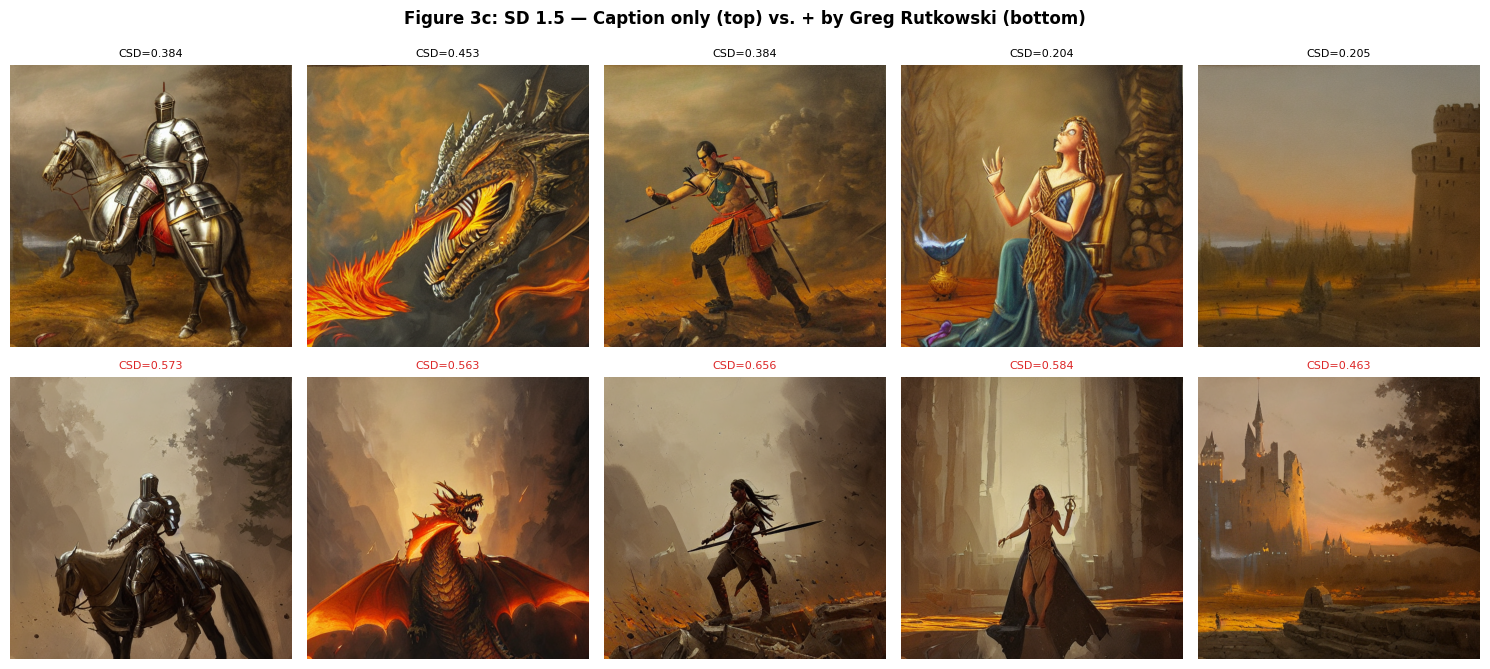

Saved: fig3c_style_gallery.png


In [62]:
# Figure 3c: Gallery — no name (top) vs + by Greg Rutkowski (bottom), first 5 prompts
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle("Figure 3c: SD 1.5 — Caption only (top) vs. + by Greg Rutkowski (bottom)",
             fontsize=12, fontweight="bold")

for row, (gens_list, label, color) in enumerate([
    (sd15_no_name,   "no name",             "black"),
    (sd15_with_name, "+ by Greg Rutkowski", "#dc2626"),
]):
    axes[row][0].set_ylabel(label, fontsize=9, fontweight="bold", color=color)
    for col in range(5):
        gen = gens_list[col][0]
        emb = get_style_embedding(gen["image"])
        sim = cosine_sim(emb, rutkowski_proto)
        axes[row][col].imshow(gen["image"])
        axes[row][col].set_title(f"CSD={sim:.3f}", fontsize=8,
                                  color="#dc2626" if row == 1 else "black")
        axes[row][col].axis("off")

for col in range(5):
    p = BASE_PROMPTS[col].replace("a painting of ", "")
    axes[0][col].set_xlabel(p, fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig3c_style_gallery.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig3c_style_gallery.png")


---
## Save Results

In [63]:
import json as _json

def _convert(o):
    import numpy as np
    if isinstance(o, np.ndarray): return o.tolist()
    if isinstance(o, (np.float32, np.float64)): return float(o)
    if isinstance(o, (np.int32, np.int64)): return int(o)
    if isinstance(o, dict): return {k: _convert(v) for k, v in o.items()}
    if isinstance(o, list): return [_convert(v) for v in o]
    return o

results_path = os.path.join(RESULTS_DIR, "results_4a.json")
with open(results_path, "w") as f:
    _json.dump(_convert(results), f, indent=2)
print(f"Saved: {results_path}")
print(_json.dumps(_convert(results), indent=2))


Saved: /content/drive/Othercomputers/laptop/research/diffusion_art/results/results_4a.json
{
  "sec4": {
    "gss_base": 0.2487714746889348,
    "gss_named": 0.529807186126709,
    "gap": 0.28103571143777417,
    "n_images": 30
  }
}
